In [567]:
import torch 
import torch.nn.functional as F

names = open("names.txt").read().splitlines()

chars = sorted(list(set(''.join(names))))
stoi = {ch: i+1 for i, ch in enumerate(chars)}
stoi['.'] = 0
itos = {i: ch for ch, i in stoi.items()}    
block_size = 5

def build_dataset(names):
    X, Y = [], []

    for w in names: 
        context = block_size * [0]
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print(''.join(itos[i] for i in context), '->', itos[ix])
            context = context[1:] + [ix]
    

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

import random
random.seed(42)
random.shuffle(names)

n1 = int(.8 * len(names))
n2 = int(.9 * len(names))
Xtr, Ytr = build_dataset(names[:n1])
Xdev, Ydev = build_dataset(names[n1:n2])
Xtest, Ytest = build_dataset(names[n2:])


In [569]:
# seed for replication
g = torch.Generator().manual_seed(2147483647)
# constants
num_chars = len(stoi)
emb_dim = 10

hp_neurons = 300 

steps = 200000
minibatch_size = 64

# embeddings 
C = torch.randn(len(stoi), emb_dim, generator=g)

# layer 1 
l1_size = block_size*emb_dim
W1 = torch.randn(l1_size, hp_neurons, generator=g)
b1 = torch.randn(hp_neurons, generator=g)
# torch.cat(torch.unbind(emb, 1), 1) == emb.view(32, 6)

# layer 2
W2 = torch.randn(hp_neurons, num_chars, generator=g)
b2 = torch.randn(num_chars, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True
print(sum(p.nelement() for p in parameters))
lri = []
lossi = []
stepi = []


23697


In [570]:
for i in range(steps):
    #minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (minibatch_size,))

    # forward pass 
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,l1_size) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix])
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < steps/2 else 0.01
    for p in parameters: 
        p.data -= lr * p.grad
    
    #track stats
    #lri.append(lre[i])
    lossi.append(loss.log10().item())
    stepi.append(i)
print(loss.item())


2.2760009765625


In [571]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,l1_size) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1495, grad_fn=<NllLossBackward0>)

In [572]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,l1_size) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1825, grad_fn=<NllLossBackward0>)

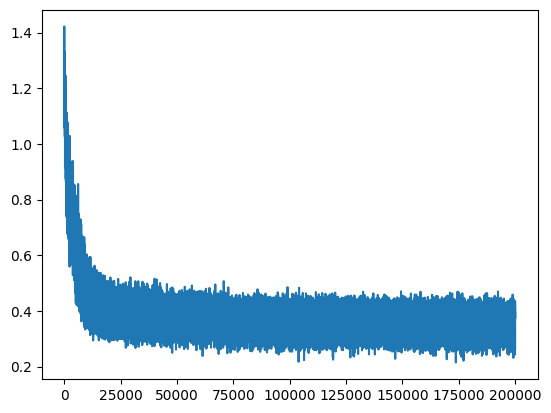

In [543]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(stepi, lossi)

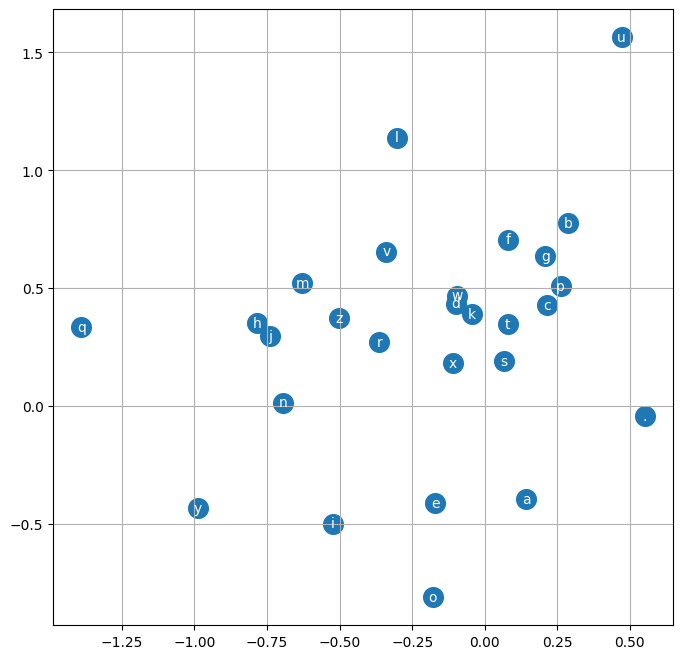

In [507]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [566]:
# sample from the model
#g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

joey.
marcentlyn.
mari.
koraleeus.
jisabrin.
ella.
zyie.
zarie.
kel.
catiyub.
delah.
jouri.
avri.
kayah.
dakarkeeb.
taisa.
apaithmundo.
abelese.
jaleen.
doro.
